<a href="https://colab.research.google.com/github/kvlaskarolina/JU-sem6-IAI/blob/main/Karolina_Kulas_PSI_01_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.family": "serif",
    'mathtext.fontset': 'dejavuserif'
})

In [ ]:
def generate_spiral_data(num_samples: int):
    N = num_samples // 2

    theta = np.sqrt(np.random.rand(N))*4*np.pi

    r_a = 4*theta + np.pi
    data_a = np.array([np.cos(theta)*r_a, np.sin(theta)*r_a]).T
    x_a = data_a + np.random.randn(N,2) * 3
    label_a = np.array([0]*N)[:, None]


    r_b = -4*theta - np.pi
    data_b = np.array([np.cos(theta)*r_b, np.sin(theta)*r_b]).T
    x_b = data_b + np.random.randn(N,2) * 3
    label_b = np.array([1]*N)[:, None]

    x = np.concatenate([x_a, x_b], axis=0)
    x /= np.std(x, axis=0)
    y = np.concatenate([label_a, label_b], axis=0)
    return x*10 + 8, y.squeeze()

## Zadanie 0. Wygeneruj zbiór danych

In [ ]:
np.random.seed(42)

days = 100
data = {
    'Date': pd.date_range(start='2023-01-01', periods=days),
    'Temperature_C': np.random.uniform(-5, 35, days),
    'Sunlight_Hours': np.random.uniform(0, 14, days),
}

production = data['Sunlight_Hours'] * (data['Temperature_C'] + 20) * 0.5 + np.random.normal(0, 5, days)
data['Energy_Production_kWh'] = np.maximum(production, 0)

df_gen = pd.DataFrame(data)
df_gen.to_csv('solar_energy.csv', index=False)

print("File 'solar_energy.csv' has been generated.")

File 'solar_energy.csv' has been generated.


## Zadanie 1. Pandas - ładowanie danych + wstępna analiza

Załaduj `solar_energy.csv` korzystając z funkcji pandasowej.

Wyświetl podstawowe statystyki danych korzystając z funkcji `describe`.

Stwórz nowy DataFrame `df_sunny`, który ma tylko takie dane, gdzie `Sunlight_Hours` są większe niż średnia produkcja w całym datasecie.

Wyświetl pierwsze 3 rzędy `df_sunny`


In [ ]:
import pandas as pd

df = pd.read_csv('solar_energy.csv')

print(df.describe())
print("-" * 30)

print(df)
print("-" * 30)

mean_production = df['Sunlight_Hours'].mean() # wg polecenia mean_production = df['Energy_Production_kWh'].mean(), ale to nie ma sensu
df_sunny = df[df['Sunlight_Hours'] > mean_production]

print(df_sunny.head(3))

       Temperature_C  Sunlight_Hours  Energy_Production_kWh
count     100.000000      100.000000             100.000000
mean       13.807230        6.969644             117.583732
std        11.899576        4.103558              82.605185
min        -4.779115        0.097330               0.000000
25%         2.728030        3.388063              51.145338
50%        13.565698        7.078748             106.569795
75%        24.208125       10.726570             165.559050
max        34.475477       13.799106             356.312775
------------------------------
          Date  Temperature_C  Sunlight_Hours  Energy_Production_kWh
0   2023-01-01       9.981605        0.440009               3.195958
1   2023-01-02      33.028572        8.909746             237.396817
2   2023-01-03      24.279758        4.400984              98.902609
3   2023-01-04      18.946339        7.119990             135.077010
4   2023-01-05       1.240746       12.705931             144.270593
..         ... 

## Zadanie 2. Numpy - reshaping i mnożenie macierzowe

Pamiętaj aby w tym zadaniu nie używać żadnych pętli. Należy korzystać z operacji wektorowych.

Chcemy obliczyć teoretyczny potencjał korzystając z następującej formuły:

```
potential = w1 * temperature + w2 * sunlight + bias
```

1. Wyciągnij dane `Temperature_C` oraz `Sunlight_Hours` z DataFrame i przekonwertuj je na ndarray.

2. Zreshapuj je tak aby z shape `(100,)` zrobić shape `(100, 1)`.

3. Skonkatenuj je horyzontalnie tak aby uzyskać macierz X o kształcie `(100, 2)`.

4. Stwórz macierz wag W o kształcie `(2, 1)` i wartościach `[[0.5], [2.0]]`.

5. Wykonaj mnożenie macierzowe dwóch macierzy

6. Dodaj bias, np o wartości 10.

7. Wyprintuj finalny shape wyniku

In [ ]:
import numpy as np

temp = df['Temperature_C'].values
sun = df['Sunlight_Hours'].values

# -1 - automatycznie dopasuj ten wymiar
temp_reshaped = temp.reshape(-1, 1)
sun_reshaped = sun.reshape(-1, 1)

# skladamy macierz na 2x100
X = np.hstack([temp_reshaped, sun_reshaped])

# macierz wag
W = np.array([[0.5], [2.0]])

# mnozenie -- [100x2] * [2x1] = [100x1]
potential = np.matmul(X, W)

bias = 10
final_potential = potential + bias

print(f"Kształt macierzy X: {X.shape}")
print(f"Kształt wag W: {W.shape}")
print(f"Kształt wyniku końcowego: {final_potential.shape}")

print("\nPierwsze 5 obliczonych wartości potencjału:")
print(final_potential[:5])

Kształt macierzy X: (100, 2)
Kształt wag W: (2, 1)
Kształt wyniku końcowego: (100, 1)

Pierwsze 5 obliczonych wartości potencjału:
[[15.87081958]
 [44.33377764]
 [30.94184631]
 [33.71314904]
 [36.03223408]]


## Zadanie 3. Matplotlib - wizualizacja

Zwizualizuj wyniki z poprzedniego zadania oraz te z CSV.

1. Stwórz scatter plot
2. Wyplotuj `Energy_Production_kWh` (te prawdziwą wartość z csv) jako niebieską linie albo kropki
3. Wyplotuj `theoretical_potential` obliczony w poprzednim zadaniu jako czerwoną linię lub kropki.
4. Dodaj legendę i opisz osie X i Y

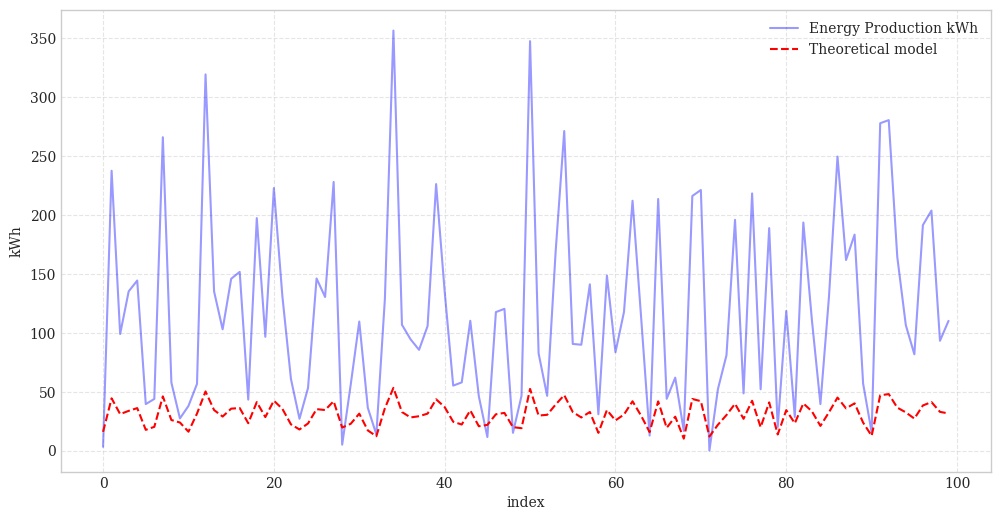

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(df.index, df['Energy_Production_kWh'], '-', color='blue',
         label='Energy Production kWh', alpha=0.4, markersize=4)

plt.plot(df.index, final_potential.flatten(), '--', color='red',
         label='Theoretical model', linewidth=1.5)

plt.xlabel('index')
plt.ylabel('kWh')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## Zadanie 4. Pytorch - manipulacja tensorami.

W deep learningu często modele pracują na 3D lub 4D tensorach (np. `[batch_size, sequence_lenght, features]`).

1. Skonwertuj macierz X z zadania 2 do Tensora. Upewnij się, że `dtype=float32`.

2. Dodaj dodatkowy wymiar do otrzymanej macierzy, który będzie symulował batch. Shape ma wyglądać następująco `[1, 100, 2]`.

3. Udawajmy, że chcemy to podać do RNNa, który analizuje sekwencje 10dniowe. Musisz zatem zreshapować otrzymany tensor do wymiaru `[10, 10, 2]`.

In [ ]:
import torch

X_tensor = torch.tensor(X, dtype=torch.float32)
print(f"Base Tensor shape: {X_tensor.shape}")

X_unsqueezed = X_tensor.unsqueeze(0)
print(f"Unsqueezed shape: {X_unsqueezed.shape}")

X_rnn = X_unsqueezed.view(10, 10, 2)
print(f"RNN Input shape: {X_rnn.shape}")

print("\nFirst sequence in the batch (first 2 days):")
print(X_rnn[0, :2, :])

Base Tensor shape: torch.Size([100, 2])
Unsqueezed shape: torch.Size([1, 100, 2])
RNN Input shape: torch.Size([10, 10, 2])

First sequence in the batch (first 2 days):
tensor([[ 9.9816,  0.4400],
        [33.0286,  8.9097]])


## Zadanie 5: NumPy i Wektoryzacja
W uczeniu maszynowym operujemy na ogromnych macierzach danych. Używanie standardowych pętli `for` w Pythonie drastycznie spowalnia obliczenia. Waszym zadaniem jest napisanie funkcji obliczającej odległość euklidesową między punktami, wykorzystując mechanizm **broadcasting'u** w NumPy. Nie możecie użyć ani jednej pętli `for`!

In [ ]:
import numpy as np

A = np.random.rand(100, 2)
B = np.array([[0.5, 0.5]])

def find_closest_vectorized(A, B):
    diff = A - B
    dist_sq = np.sum(diff**2, axis=1)
    distances = np.sqrt(dist_sq)
    return np.argmin(distances)
    pass

closest_index = find_closest_vectorized(A, B)
print(f"Index of the closest point: {closest_index}")
print(f"Coordinates of the closest point: {A[closest_index]}")

Index of the closest point: 8
Coordinates of the closest point: [0.49161588 0.47347177]


## Zadanie 6: Pandas i Czyszczenie Danych
Zanim dane trafią do sieci neuronowej, muszą zostać oczyszczone (tzw. preprocessing). Poniżej znajduje się słownik z logami z treningu różnych modeli. Zamień go na DataFrame, usuń wiersze z brakującą wartością funkcji straty (`loss`), a następnie oblicz średni czas treningu dla każdej z architektur.


In [ ]:
data_logs = {
    'model_id': [1, 2, 3, 4, 5, 6],
    'model_type': ['CNN', 'Transformer', 'CNN', 'Transformer', 'MLP', 'MLP'],
    'loss': [0.45, np.nan, 0.22, 0.11, 0.85, np.nan],
    'training_time_s': [120, 450, 110, 500, 45, 50]
}

'''
 1. Convert the dictionary to a pandas DataFrame
 2. Drop rows where ONLY the 'loss' column has a NaN value
 3. Group by model type and calculate the mean of training time
 4. Display the results
'''

df_logs = pd.DataFrame(data_logs)
df_cleaned = df_logs.dropna(subset=['loss'])
mean_times = df_cleaned.groupby('model_type')['training_time_s'].mean()

print("df_cleaned")
print(df_cleaned)
print("-" * 30)
print("mean_times (s):")
print(mean_times)

df_cleaned
   model_id   model_type  loss  training_time_s
0         1          CNN  0.45              120
2         3          CNN  0.22              110
3         4  Transformer  0.11              500
4         5          MLP  0.85               45
------------------------------
mean_times (s):
model_type
CNN            115.0
MLP             45.0
Transformer    500.0
Name: training_time_s, dtype: float64


## Zadanie 7: Matplotlib i Krzywa Uczenia (Loss Curve)
Podstawowym narzędziem do diagnozowania modeli AI jest wykres funkcji straty. Waszym zadaniem jest zasymulowanie spadku błędu modelu na przestrzeni 50 epok i narysowanie czytelnego wykresu. Dodajcie również poziomą linię oznaczającą próg akceptacji błędu.


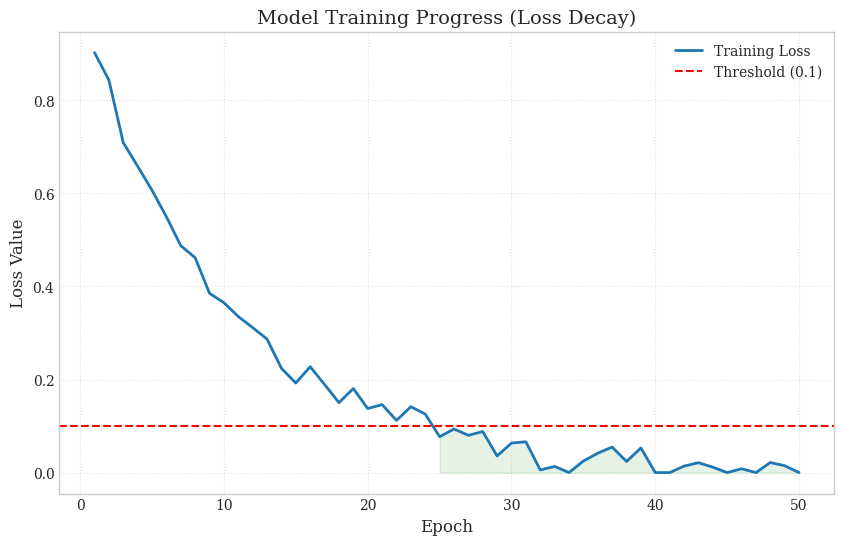

In [ ]:
'''
1. Generate epochs (1 to 50)
2. Simulate training loss (exponential decay) and add some random noise
3. Plot the main loss curve
4. Add a horizontal dashed line for the acceptable loss threshold (e.g., y=0.1)
5. Add aesthetic elements: title, labels, and legend
'''
import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1, 51)

loss = np.exp(-0.1 * epochs) + np.random.normal(0, 0.02, size=len(epochs))

loss = np.maximum(loss, 0)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, label='Training Loss', color='#1f77b4', linewidth=2)

threshold = 0.1
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')

plt.title('Model Training Progress (Loss Decay)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.fill_between(epochs, 0, loss, where=(loss <= threshold), color='green', alpha=0.1, label='Target Reached')

plt.show()

## Zadanie 8: PyTorch, Autograd i Akceleracja GPU
Zrozumienie, jak działają tensory i automatyczne różniczkowanie (`autograd`), to fundament pracy z PyTorchem i algorytmem wstecznej propagacji błędu (backpropagation). Zbudujcie prosty graf obliczeniowy, policzcie gradient względem wagi modelu i sprawdźcie, czy środowisko obsługuje sprzętową akcelerację (GPU).


In [ ]:
'''
1. Define input scalar 'x'
2. Define weight scalar 'w'.
3. Perform a mathematical operation (forward pass)
Equation: y = w * (x^2) + 5
4. Perform backpropagation (compute derivatives)
5. Print the gradient of y with respect to w (dy/dw)
6. Check for GPU availability (CUDA for NVIDIA, MPS for Apple Silicon) and move a tensor there
7. Create a random 100x100 tensor and send it to the selected device
'''
import torch

w = torch.tensor(3.0, requires_grad=True)
x = torch.tensor(2.0)

y = w * (x**2) + 5

#rozniczkowanie
y.backward()
print(f"Gradient of y with respect to w: {w.grad}")

device = torch.device("cuda" if torch.cuda.is_available() else
                     "mps" if torch.backends.mps.is_available() else "cpu")

gpu_tensor = torch.randn(100, 100).to(device)
print(f"Tensor is currently on: {gpu_tensor.device}")

Gradient of y with respect to w: 4.0
Tensor is currently on: cpu


## Zadanie 9 - NumPy

Wykorzystując bibliotekę NumPy, utwórz macierz o wymiarach 8x8, wypełnioną zerami i jedynkami układającymi się naprzemiennie we wzór szachownicy. Zadanie rozwiąż w maksymalnie trzech linijkach kodu. Nie używaj pętli.

In [ ]:
chessboard = np.zeros((8, 8), dtype=int)

chessboard[1::2, 1::2] = chessboard[::2, ::2] = 1 # Odd columns in even rows, then Even columns in odd rows

print(chessboard)

[[1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]]


## Zadanie 10 - Pandas

Wykorzystując biblioteki NumPy i Pandas, utwórz obiekt DataFrame składający się z dokładnie 100 obserwacji, reprezentujący dowolną, wybraną przez Ciebie dziedzinę. Wymagane jest wygenerowanie:

- Minimum dwóch kolumn numerycznych opartych na dowolnym ciągłym rozkładzie (stanowiących zmienne objaśniające/cechy).

- Jednej kolumny kategorycznej zawierającej losowo przypisane wartości z zamkniętej puli (minimum 3 elementy).

- Zmiennej docelowej, która jest zdefiniowana jako funkcja matematyczna oparta na wygenerowanych wcześniej cechach numerycznych, do której należy dodać losowy szum (np. z rozkładu normalnego), aby zasymulować realistyczne dane.

Unikaj iteracyjnego dodawania wierszy lub kolumn. Wypisz wybrane statystyki zbioru.

Przykład: X = [moc silnika, wiek auta, marka], y = [cena]

In [ ]:
import numpy as np
import pandas as pd

n_samples = 100
districts = ['Suburbs', 'Downtown', 'Industrial']

sq_footage = np.random.normal(120, 30, n_samples)
distance_km = np.random.exponential(5, n_samples)

district_labels = np.random.choice(districts, n_samples)

district_impact = np.select(
    [district_labels == 'Downtown', district_labels == 'Industrial'],
    [50000, -20000],
    default=0
)

noise = np.random.normal(0, 15000, n_samples)
price = (sq_footage * 3000) - (distance_km * 5000) + district_impact + 100000 + noise

df_housing = pd.DataFrame({
    'Square_Footage': sq_footage,
    'Distance_to_Center': distance_km,
    'District': district_labels,
    'Price_USD': price
})

print("Dataset Statistics")
print(df_housing.describe())
print("\n Categorical Distribution")
print(df_housing['District'].value_counts())
print("\n First 5 Rows")
print(df_housing.head())

Dataset Statistics
       Square_Footage  Distance_to_Center      Price_USD
count      100.000000          100.000000     100.000000
mean       122.590574            4.926090  453324.758375
std         29.294914            4.631205  104759.456413
min         42.783465            0.040163  123948.669320
25%        104.408718            1.826823  383848.903279
50%        122.181647            3.197255  450733.079687
75%        137.670017            6.883249  520889.309518
max        213.233066           25.275605  770613.419421

 Categorical Distribution
District
Suburbs       35
Downtown      34
Industrial    31
Name: count, dtype: int64

 First 5 Rows
   Square_Footage  Distance_to_Center    District      Price_USD
0      168.702430           12.924189    Downtown  593630.216370
1      117.338748            8.370860     Suburbs  410693.817367
2      129.557836            1.011184  Industrial  448543.502719
3      100.737114            1.075985     Suburbs  390790.706317
4      132.8028

## Zadanie 11 - Scikit-learn

Wykorzystując syntetyczny zbiór danych wygenerowany w poprzednim kroku, przygotuj zmienne objaśniające ($X$) oraz zmienną docelową ($y$). Pamiętaj o konieczności przekształcenia kolumny kategorycznej do postaci numerycznej odpowiedniej dla modeli liniowych - rozważ różne metody.
Podziel zbiór na część treningową i testową (w proporcji 80/20).
Wytrenuj prosty model regresji.
Oblicz i wypisz na ekranie wartość błędu średniokwadratowego (MSE) zarówno dla zbioru treningowego, jak i testowego.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

df_final = pd.get_dummies(df_housing, columns=['District'], drop_first=True)

X = df_final.drop('Price_USD', axis=1)
y = df_final['Price_USD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

mse_train = mean_squared_error(y_train, train_preds)
mse_test = mean_squared_error(y_test, test_preds)

rmse_test = np.sqrt(mse_test)

print(f"Training MSE: {mse_train:,.2f}")
print(f"Test MSE:     {mse_test:,.2f}")
print(f"Avg. Error:   ${rmse_test:,.2f} USD")

Training MSE: 268,296,823.19
Test MSE:     264,849,076.37
Avg. Error:   $16,274.18 USD


## Zadanie 12 - PyTorch

Wykorzystując bibliotekę PyTorch, zdefiniuj jednowymiarowy tensor $x$. Następnie zdefiniuj funkcję kwadratową $y$. Uruchom propagację wsteczną i wypisz na ekranie obliczoną wartość pochodnej funkcji $y$ po zmiennej $x$.

In [ ]:
import torch

# 1D tensor 'x'
x = torch.tensor(4.0, requires_grad=True)

y = x**2 + x -7

y.backward()

print(f"x= {x.item()}")
print(f"x^2= {y.item()}")
print(f"dy/dx at x={x.item()}: {x.grad.item()}")

x= 4.0
x^2= 13.0
dy/dx at x=4.0: 9.0


## Zadanie 13

- Use `x, y = generate_spiral_data(NUM_SAMPLES)` to generate a `2D` dataset of `500` samples, where `x` represents samples and `y` corresponding labels.  

- Write a function in matplotlib that visualizes those samples (Use `scatter` to plot samples, and use `y` as color labels)

- What do you notice about data range?

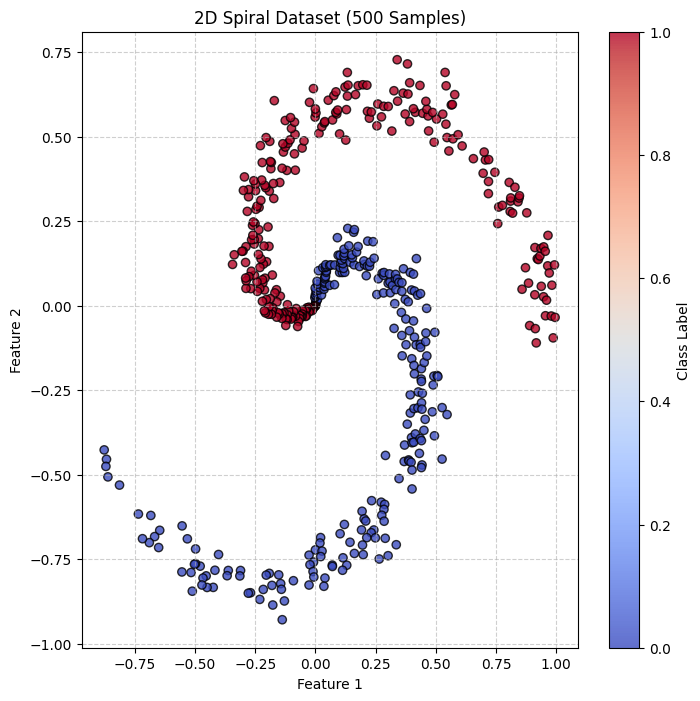

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_spiral_data(num_samples):
    """
    Generates a 2D spiral dataset with 2 classes.
    """
    points_per_class = num_samples // 2
    dims = 2

    x = np.zeros((num_samples, dims))
    y = np.zeros(num_samples, dtype=int)

    for class_idx in range(2):
        ix = range(points_per_class * class_idx, points_per_class * (class_idx + 1))
        r = np.linspace(0.0, 1, points_per_class)
        t = np.linspace(class_idx * 4, (class_idx + 1) * 4, points_per_class) + np.random.randn(points_per_class) * 0.2 # theta

        x[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        y[ix] = class_idx

    return x, y

def plot_spiral_data(x, y):
    """
    Visualizes the 2D samples using a scatter plot.
    """
    plt.figure(figsize=(8, 8))

    scatter = plt.scatter(x[:, 0], x[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.8)

    plt.title("2D Spiral Dataset (500 Samples)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.colorbar(scatter, label='Class Label')
    plt.show()

# Execution
NUM_SAMPLES = 500
x, y = generate_spiral_data(NUM_SAMPLES)
plot_spiral_data(x, y)

## Zadanie 14

using `numpy`, check mean and std of the dataset, then normalize to mean=0, std=1 and visualize again.

Original Mean (per feature): [ 0.12610644 -0.00988858]
Original Std (per feature):  [0.36970284 0.42581906]
Normalized Mean: [4.44089210e-18 6.54365451e-16]
Normalized Std:  [1. 1.]


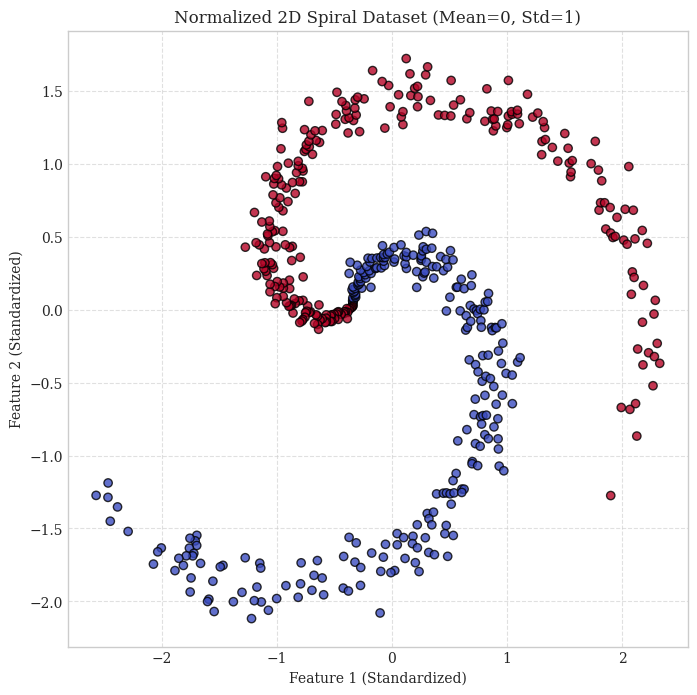

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x, y = generate_spiral_data(500)

original_mean = np.mean(x, axis=0)
original_std = np.std(x, axis=0)

print(f"Original Mean (per feature): {original_mean}")
print(f"Original Std (per feature):  {original_std}")

x_normalized = (x - original_mean) / original_std

normalized_mean = np.mean(x_normalized, axis=0)
normalized_std = np.std(x_normalized, axis=0)

print(f"Normalized Mean: {normalized_mean}")
print(f"Normalized Std:  {normalized_std}")

# 5. Visualize again
plt.figure(figsize=(8, 8))
plt.scatter(x_normalized[:, 0], x_normalized[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.8)
plt.title("Normalized 2D Spiral Dataset (Mean=0, Std=1)")
plt.xlabel("Feature 1 (Standardized)")
plt.ylabel("Feature 2 (Standardized)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Zadanie 15

Using numpy, Write a function that generates a 2D grid of coordinates covering the min-max range of a given dataset. \


```
def generate_2d_grid(x_train: np.ndarray, res: int) -> np.ndarray:
```


- use `min` and `max` operations to determine ranges on first and second coordinate
- use `linspace` to generate axis for both coordinates with `res` variable as step
- use `meshgrid` to convert axis to grids
- stack and reshape results to a shape `(res*res, 2)`

In [ ]:
import numpy as np

def generate_2d_grid(x_train: np.ndarray, res: int) -> np.ndarray:
    """
    Generates a dense 2D grid of coordinates covering the span of the input data.
    """
    x_min, x_max = x_train[:, 0].min(), x_train[:, 0].max()
    y_min, y_max = x_train[:, 1].min(), x_train[:, 1].max()

    x_axis = np.linspace(x_min, x_max, res)
    y_axis = np.linspace(y_min, y_max, res)

    xx, yy = np.meshgrid(x_axis, y_axis)

    grid = np.c_[xx.ravel(), yy.ravel()]

    return grid

grid_coords = generate_2d_grid(x_normalized, resolution)

print(f"Grid shape: {grid_coords.shape}")
print(f"First 5 coordinates:\n{grid_coords[:5]}")

Grid shape: (10000, 2)
First 5 coordinates:
[[-2.57029704 -2.11778387]
 [-2.52084    -2.11778387]
 [-2.47138296 -2.11778387]
 [-2.42192591 -2.11778387]
 [-2.37246887 -2.11778387]]


## Zadanie 16

For different values of $K \in {1, ..., 10}$
train `KNeighborsClassifier` model on `x` and `y`, then visualize its geometry with matplotlib by predicting the `grid`.

- Import `KNeighborsClassifier`
- Fit to `x` and `y`
- predict `grid` from previous task
- reshape prediction to (`res`, `res`) and visualize with `imshow`
- repeat for different values of `K`

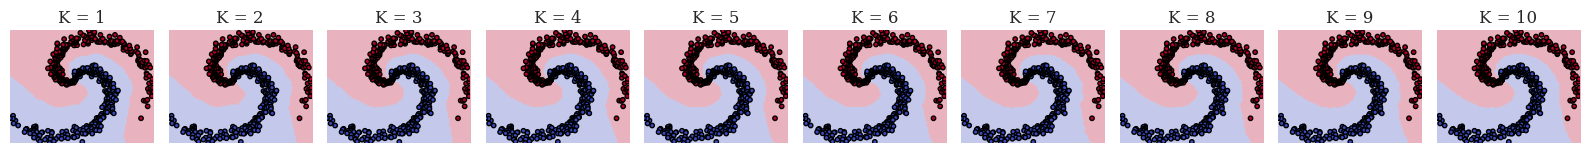

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

res = 100
grid_coords = generate_2d_grid(x_normalized, res)
k_values = [1, 2, 3, 4, 5, 6,7,8,9,10]

plt.figure(figsize=(16, 4))

for i, k in enumerate(k_values):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_normalized, y)

    grid_predictions = knn.predict(grid_coords)

    decision_surface = grid_predictions.reshape(res, res)

    plt.subplot(1, len(k_values), i + 1)

    plt.imshow(decision_surface, extent=(x_normalized[:,0].min(), x_normalized[:,0].max(),
                                         x_normalized[:,1].min(), x_normalized[:,1].max()),
               origin='lower', alpha=0.3, cmap='coolwarm')

    plt.scatter(x_normalized[:, 0], x_normalized[:, 1], c=y, cmap='coolwarm',
                edgecolors='k', s=10)

    plt.title(f"K = {k}")
    plt.axis('off')

plt.tight_layout()
plt.show()